# Lab 3 Task 3: QPSK and 8-PSK over the N310 Link

Use this notebook to calculate waveform values, generate the files used by GNU Radio, validate the receiver with synthetic data, and analyze the six real captures.

In [19]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def locate_lab_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "support" / "lab3_tools.py").is_file():
            return base
    raise FileNotFoundError("Open this notebook from its Lab 3 folder.")

LAB_ROOT = locate_lab_root()
sys.path.insert(0, str(LAB_ROOT / "support"))
WORK_DIR = LAB_ROOT / "work"
FIGURE_DIR = WORK_DIR / "figures"
WAVEFORM_DIR = WORK_DIR / "waveforms"
CAPTURE_DIR = WORK_DIR / "captures"
for path in (FIGURE_DIR, WAVEFORM_DIR, CAPTURE_DIR):
    path.mkdir(parents=True, exist_ok=True)
print("Lab root:", LAB_ROOT)

Lab root: /Users/marcpham/jupyter_notebook_files/Embedded-Wireless-Design-Labs/Lab3


## Waveform calculations

In [20]:
sample_rate_sps = 1_250_000
symbol_rate_baud = 125_000
rolloff = 0.35
span_symbols = 10
baseband_shift_hz = 200_000
guard_symbols = 24
preamble_symbols = 127
payload_symbols = 512
file_periods = 8
transmit_seconds = 20.0
signal_capture_seconds = 8.0
noise_capture_seconds = 1.0

# To Do: derive all counts from the values above.
samples_per_symbol = sample_rate_sps // symbol_rate_baud
raised_cosine_bandwidth_hz = (1 + rolloff) * symbol_rate_baud
lower_edge_hz = baseband_shift_hz - raised_cosine_bandwidth_hz / 2
upper_edge_hz = baseband_shift_hz + raised_cosine_bandwidth_hz / 2
frame_symbol_count = (guard_symbols + preamble_symbols + payload_symbols + guard_symbols)
rrc_tap_count = span_symbols * samples_per_symbol + 1
period_samples = ((frame_symbol_count - 1) * samples_per_symbol + rrc_tap_count)
waveform_file_samples = file_periods * period_samples
waveform_file_bytes = waveform_file_samples * 8
transmit_head_samples = int(transmit_seconds * sample_rate_sps)
signal_capture_samples = int(signal_capture_seconds * sample_rate_sps)
signal_capture_bytes = signal_capture_samples * 8
noise_capture_samples = int(noise_capture_seconds * sample_rate_sps)
noise_capture_bytes = noise_capture_samples * 8

In [21]:
expected = {
    "samples_per_symbol": 10,
    "frame_symbol_count": 687,
    "rrc_tap_count": 101,
    "period_samples": 6961,
    "waveform_file_samples": 55688,
    "waveform_file_bytes": 445504,
    "transmit_head_samples": 25_000_000,
    "signal_capture_samples": 10_000_000,
    "signal_capture_bytes": 80_000_000,
    "noise_capture_samples": 1_250_000,
    "noise_capture_bytes": 10_000_000,
}
for name, value in expected.items():
    assert globals()[name] == value, f"Check {name}"
print(f"Ideal shifted band: {lower_edge_hz/1e3:.3f} to {upper_edge_hz/1e3:.3f} kHz")
print("Waveform and capture calculations passed.")

Ideal shifted band: 115.625 to 284.375 kHz
Waveform and capture calculations passed.


4-PSK: task3_m4_tx_c64.dat, 445504 bytes, peak 0.100
8-PSK: task3_m8_tx_c64.dat, 445504 bytes, peak 0.100


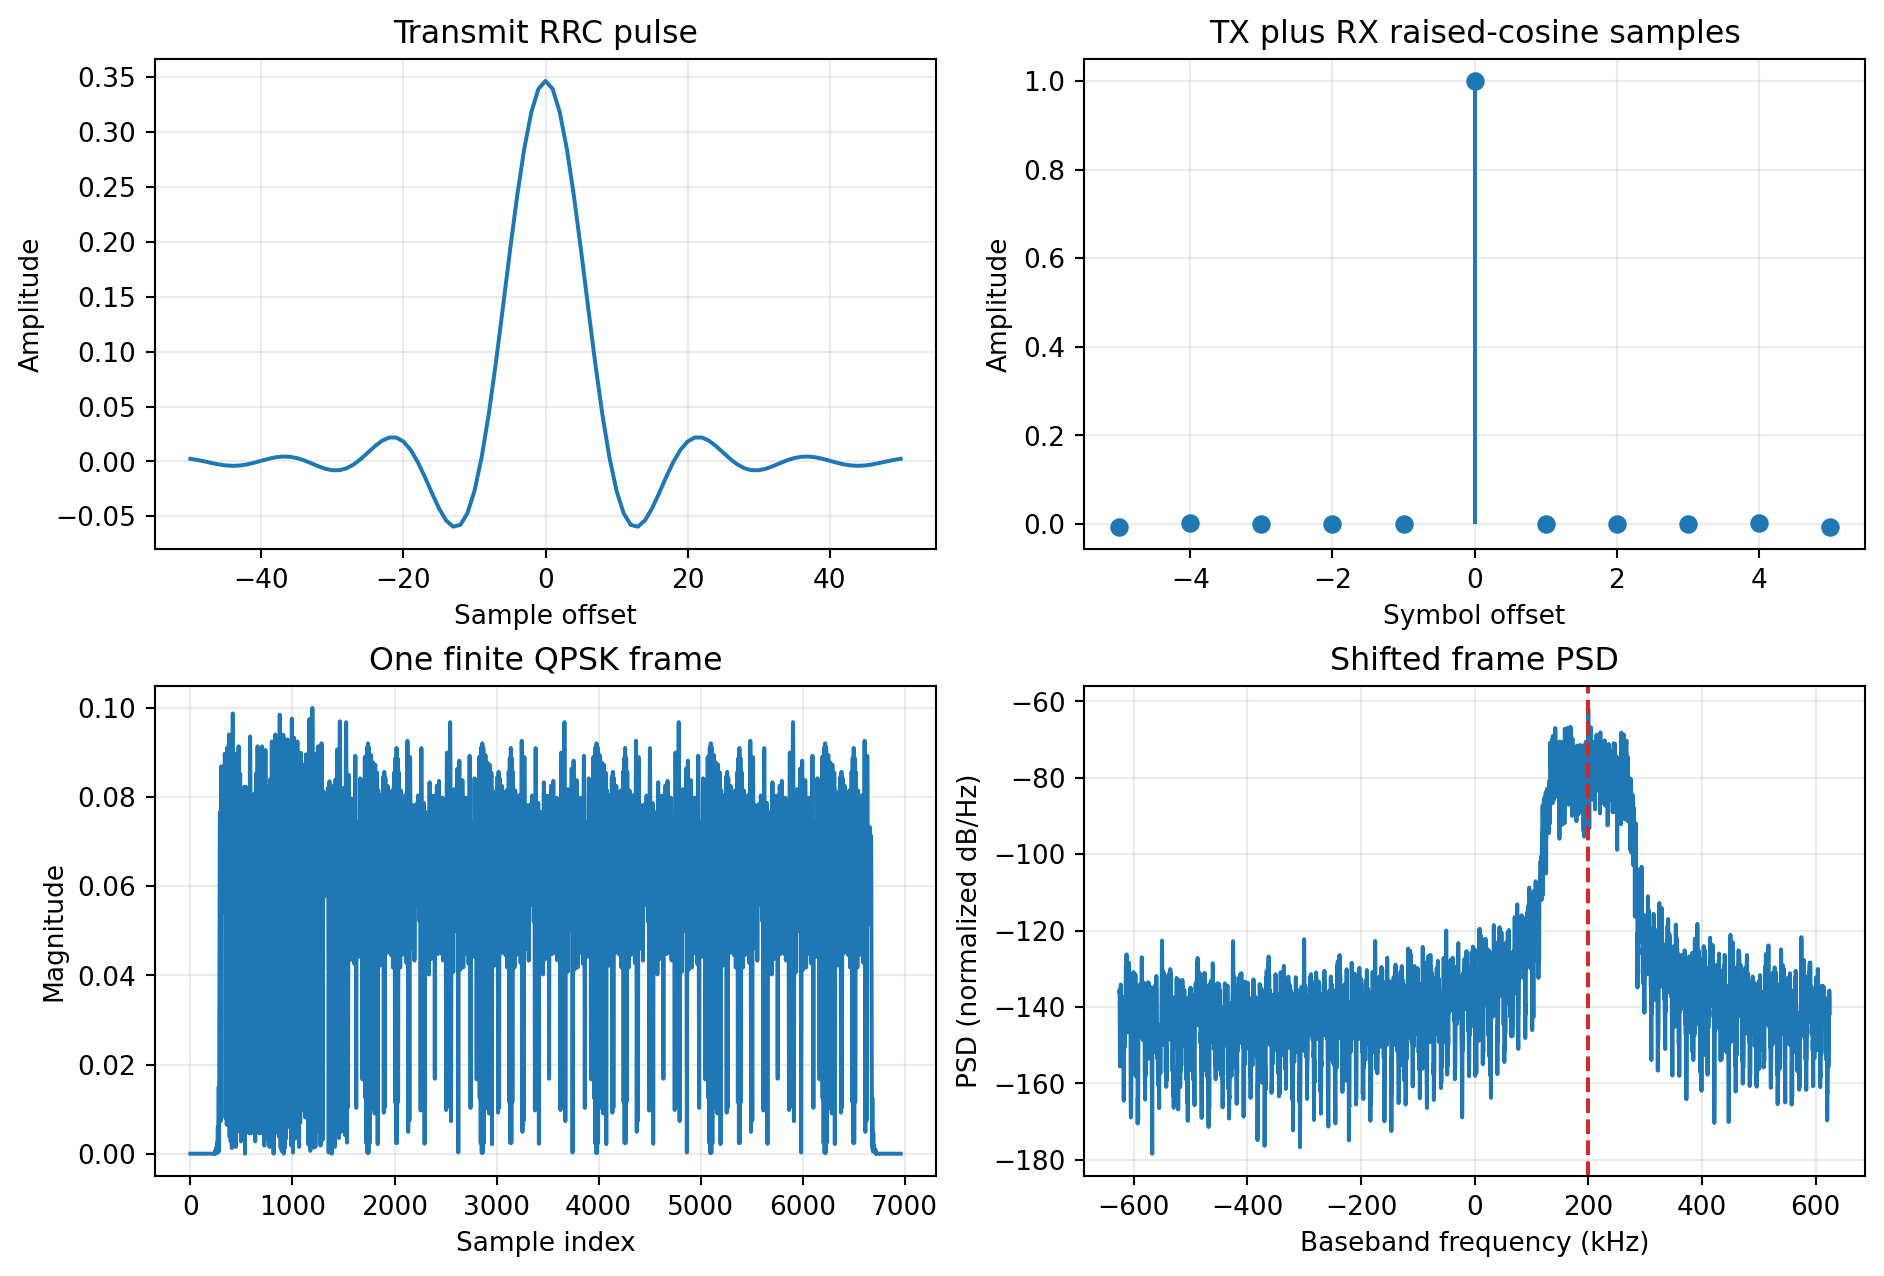

In [22]:
from lab3_tools import (
    analyze_psk_capture, build_psk_frame, make_synthetic_psk_capture,
    plot_synthetic_psk_result, plot_task3_measurements, plot_task3_waveform
)

references = {order: build_psk_frame(order, WAVEFORM_DIR) for order in (4, 8)}
(WAVEFORM_DIR / "task3_message.txt").write_text("ECE7377 LAB3 PYTHON RADIO | \n")
for order, reference in references.items():
    path = reference["waveform_path"]
    print(f"{order}-PSK: {path.name}, {path.stat().st_size} bytes, peak {np.max(np.abs(reference['finite_file'])):.3f}")
waveform_figure = plot_task3_waveform(references[4], FIGURE_DIR)
display(Image(filename=str(waveform_figure)))

<span style="color:#165696"><b>Answer in the report.</b> Verify the number of samples, bytes, duration, peak
magnitude, and PSD before opening GNU Radio.</span>

The generated waveform was verified before transmission. The frame contained 687 symbols and produced 6,961 samples after pulse shaping. Repeating the frame eight times yielded a waveform file containing 55,688 samples (445,504 bytes) with a duration of 44.5504 ms. The transmit head length was verified as 25,000,000 samples (20 s), while the signal and noise captures contained 10,000,000 samples (80,000,000 bytes) and 1,250,000 samples (10,000,000 bytes), respectively. The PSD was centered at +200 kHz as expected, with theoretical raised-cosine spectral edges at 115.625 kHz and 284.375 kHz corresponding to a bandwidth of 168.75 kHz. The waveform peak magnitude was confirmed to remain below the required limit of 0.10.

In [23]:
waveform_duration_ms = 1000 * waveform_file_samples / sample_rate_sps
frame_duration_ms = 1000 * period_samples / sample_rate_sps
tx_duration_s = transmit_head_samples / sample_rate_sps
signal_duration_s = signal_capture_samples / sample_rate_sps
noise_duration_s = noise_capture_samples / sample_rate_sps

print("=== Waveform Verification ===")
print(f"Samples/symbol       : {samples_per_symbol}")
print(f"Frame symbols        : {frame_symbol_count}")
print(f"RRC taps             : {rrc_tap_count}")

print("\n=== Frame Verification ===")
print(f"Samples/frame        : {period_samples:,}")
print(f"Frame duration       : {frame_duration_ms:.4f} ms")

print("\n=== Waveform File Verification ===")
print(f"Total samples        : {waveform_file_samples:,}")
print(f"File size            : {waveform_file_bytes:,} bytes")
print(f"Duration             : {waveform_duration_ms:.4f} ms")

print("\n=== Head/Capture Verification ===")
print(f"Transmit head        : {transmit_head_samples:,} samples ({tx_duration_s:.1f} s)")
print(f"Signal capture       : {signal_capture_samples:,} samples ({signal_duration_s:.1f} s)")
print(f"Signal file size     : {signal_capture_bytes:,} bytes")
print(f"Noise capture        : {noise_capture_samples:,} samples ({noise_duration_s:.1f} s)")
print(f"Noise file size      : {noise_capture_bytes:,} bytes")

print("\n=== PSD Verification ===")
print(f"Raised-cosine BW     : {raised_cosine_bandwidth_hz/1e3:.2f} kHz")
print(f"Expected PSD edges   : {lower_edge_hz/1e3:.3f} to {upper_edge_hz/1e3:.3f} kHz")
print(f"Center frequency     : {baseband_shift_hz/1e3:.1f} kHz")

print()
for order, reference in references.items():
    path = reference["waveform_path"]
    print(f"{order}-PSK Peak Magnitude: {np.max(np.abs(reference['finite_file'])):.3f}")

=== Waveform Verification ===
Samples/symbol       : 10
Frame symbols        : 687
RRC taps             : 101

=== Frame Verification ===
Samples/frame        : 6,961
Frame duration       : 5.5688 ms

=== Waveform File Verification ===
Total samples        : 55,688
File size            : 445,504 bytes
Duration             : 44.5504 ms

=== Head/Capture Verification ===
Transmit head        : 25,000,000 samples (20.0 s)
Signal capture       : 10,000,000 samples (8.0 s)
Signal file size     : 80,000,000 bytes
Noise capture        : 1,250,000 samples (1.0 s)
Noise file size      : 10,000,000 bytes

=== PSD Verification ===
Raised-cosine BW     : 168.75 kHz
Expected PSD edges   : 115.625 to 284.375 kHz
Center frequency     : 200.0 kHz

4-PSK Peak Magnitude: 0.100
8-PSK Peak Magnitude: 0.100


## Synthetic receiver check

Run the reference-assisted receiver on a known capture before using RF data. This test isolates receiver logic from radio setup.

<span style="color:#165696"><b>Answer in the report.</b> Report the inserted and recovered frame lags, inserted and estimated
CFO, RMS EVM, SER, BER, and decoded message.</span>

True first lag: 5000
Recovered first lag: 5000
True/estimated CFO: 85.000 / 84.997 Hz
SER=0.000000, BER=0.000000, EVM=2.146%
Decoded: ECE7377 LAB3 PYTHON RADIO | 


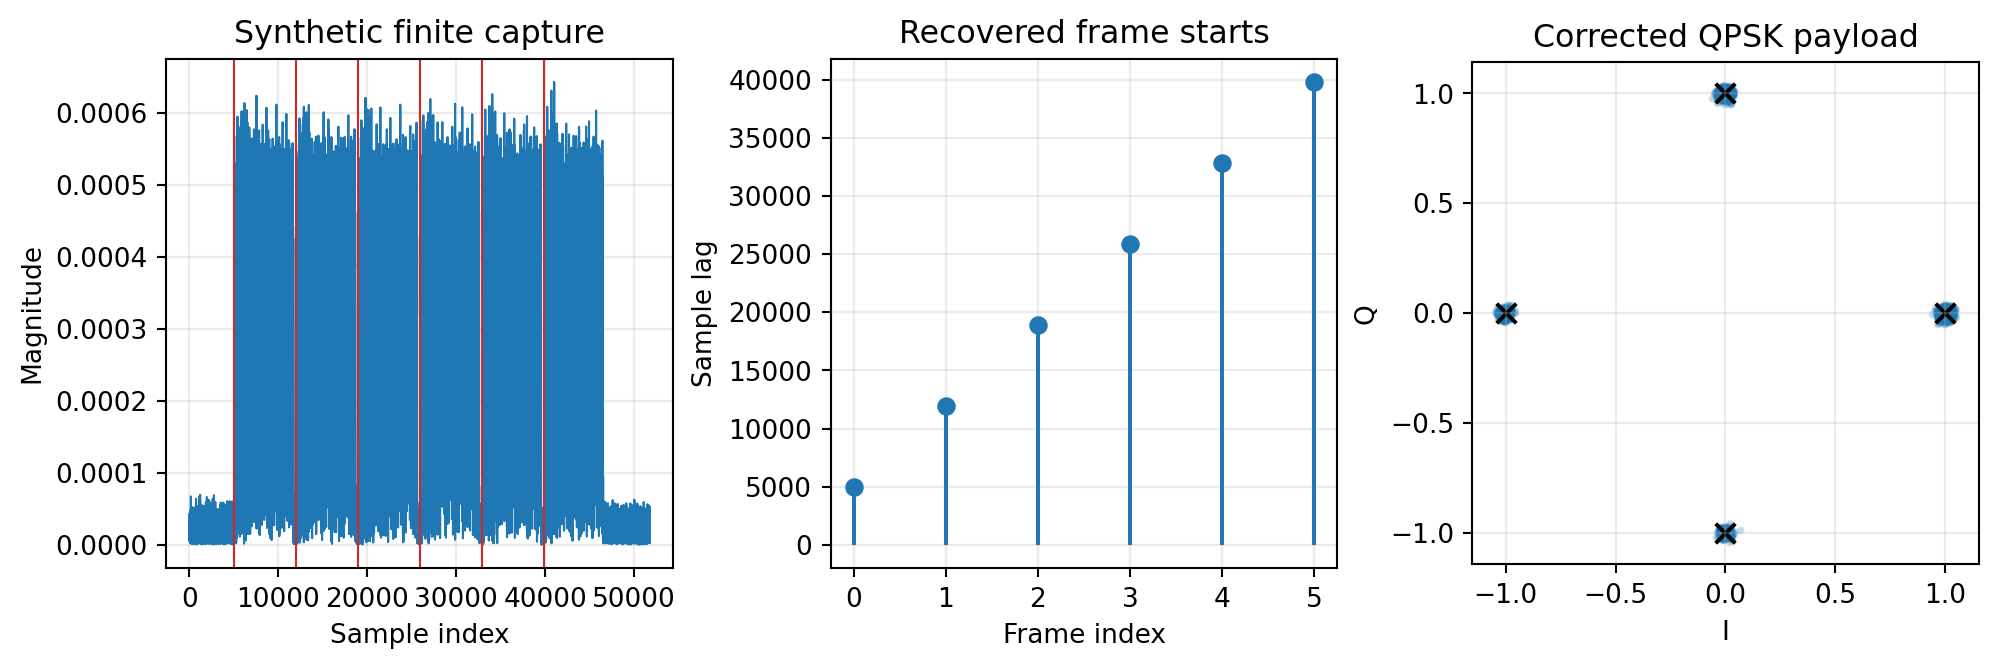

In [24]:
synthetic_dir = WORK_DIR / "synthetic"
synthetic_capture, synthetic_noise, truth = make_synthetic_psk_capture(
    references[4], synthetic_dir
)
synthetic_result = analyze_psk_capture(
    synthetic_capture, synthetic_noise, references[4], maximum_frames=6
)
synthetic_figure = plot_synthetic_psk_result(
    synthetic_capture, synthetic_result, references[4], FIGURE_DIR
)
print("True first lag:", truth["true_lag"])
print("Recovered first lag:", int(synthetic_result["correlation_lags"][0]))
print(f"True/estimated CFO: {truth['true_cfo_hz']:.3f} / {synthetic_result['cfo_hz']:.3f} Hz")
print(f"SER={synthetic_result['ser']:.6f}, BER={synthetic_result['ber']:.6f}, EVM={synthetic_result['evm_percent']:.3f}%")
print("Decoded:", synthetic_result["decoded_prefixes"][0])
display(Image(filename=str(synthetic_figure)))

<span style="color:#165696"><b>Answer in the report.</b> Explain why using the complete payload for
alignment and correction is an oracle measurement rather than an autonomous receiver</span>

Using the complete payload for alignment and correction is an oracle measurement because the receiver already knows the transmitted data. This allows timing, frequency, and phase errors to be estimated using information that would not be available in a real receiver. An autonomous receiver must recover synchronization using only preamble or training symbols without prior knowledge of the payload.

## GNU Radio capture sequence

Open `flowgraphs/lab3_finite_receiver.grc` on the RX desktop and `flowgraphs/lab3_finite_file_transmitter.grc` on the TX desktop.

1. In each UHD block, enter the assigned `addr=...`, subdevice, and antenna.
2. Verify 2.45 GHz, 1.25 MS/s, one channel, and the intended gain.
3. With the transmitter stopped, set the receiver to 1.0 second and save `task3_noise_c64.dat`.
4. For each modulation and gain, set the receiver to 8.0 seconds and choose a unique output filename.
5. Start the 20.0-second transmitter first, then start the receiver.
6. Confirm 10,000,000 samples and 80,000,000 bytes for every signal record.

The repeated File Source and 20-second finite Head give independently initialized N310 flowgraphs enough overlap. The Head block stops transmission after exactly 25,000,000 samples. No Throttle block is used because UHD controls the stream rate.

<span style="color:#165696"><b>Answer in the report.</b> For each flowgraph, identify the file, source, finite-length, UHD, and
sink stages. Record which variables contain the server-supplied radio assignment. Explain why the
transmitter File Source repeats, why the Head still makes the operation finite, and why there is no
Throttle block in a hardware streaming path.</span>

The transmitter flowgraph consists of a File Source (tx_file) that reads the complex64 waveform, a Head block (transmit_samples = 25,000,000) that limits the transmission length, and a UHD USRP Sink that sends the samples over the assigned radio. The server-supplied radio assignment is stored in the variables tx_device_args, tx_subdevice, and tx_antenna. The File Source is set to repeat so that the waveform is always available to the USRP, even if transmitter and receiver startup times are not perfectly synchronized. This prevents the transmitter from reaching the end of the file before the receiver begins recording. However, the Head block still makes the transmission finite by passing only 25,000,000 samples, after which the flowgraph stops regardless of how many times the file could repeat.

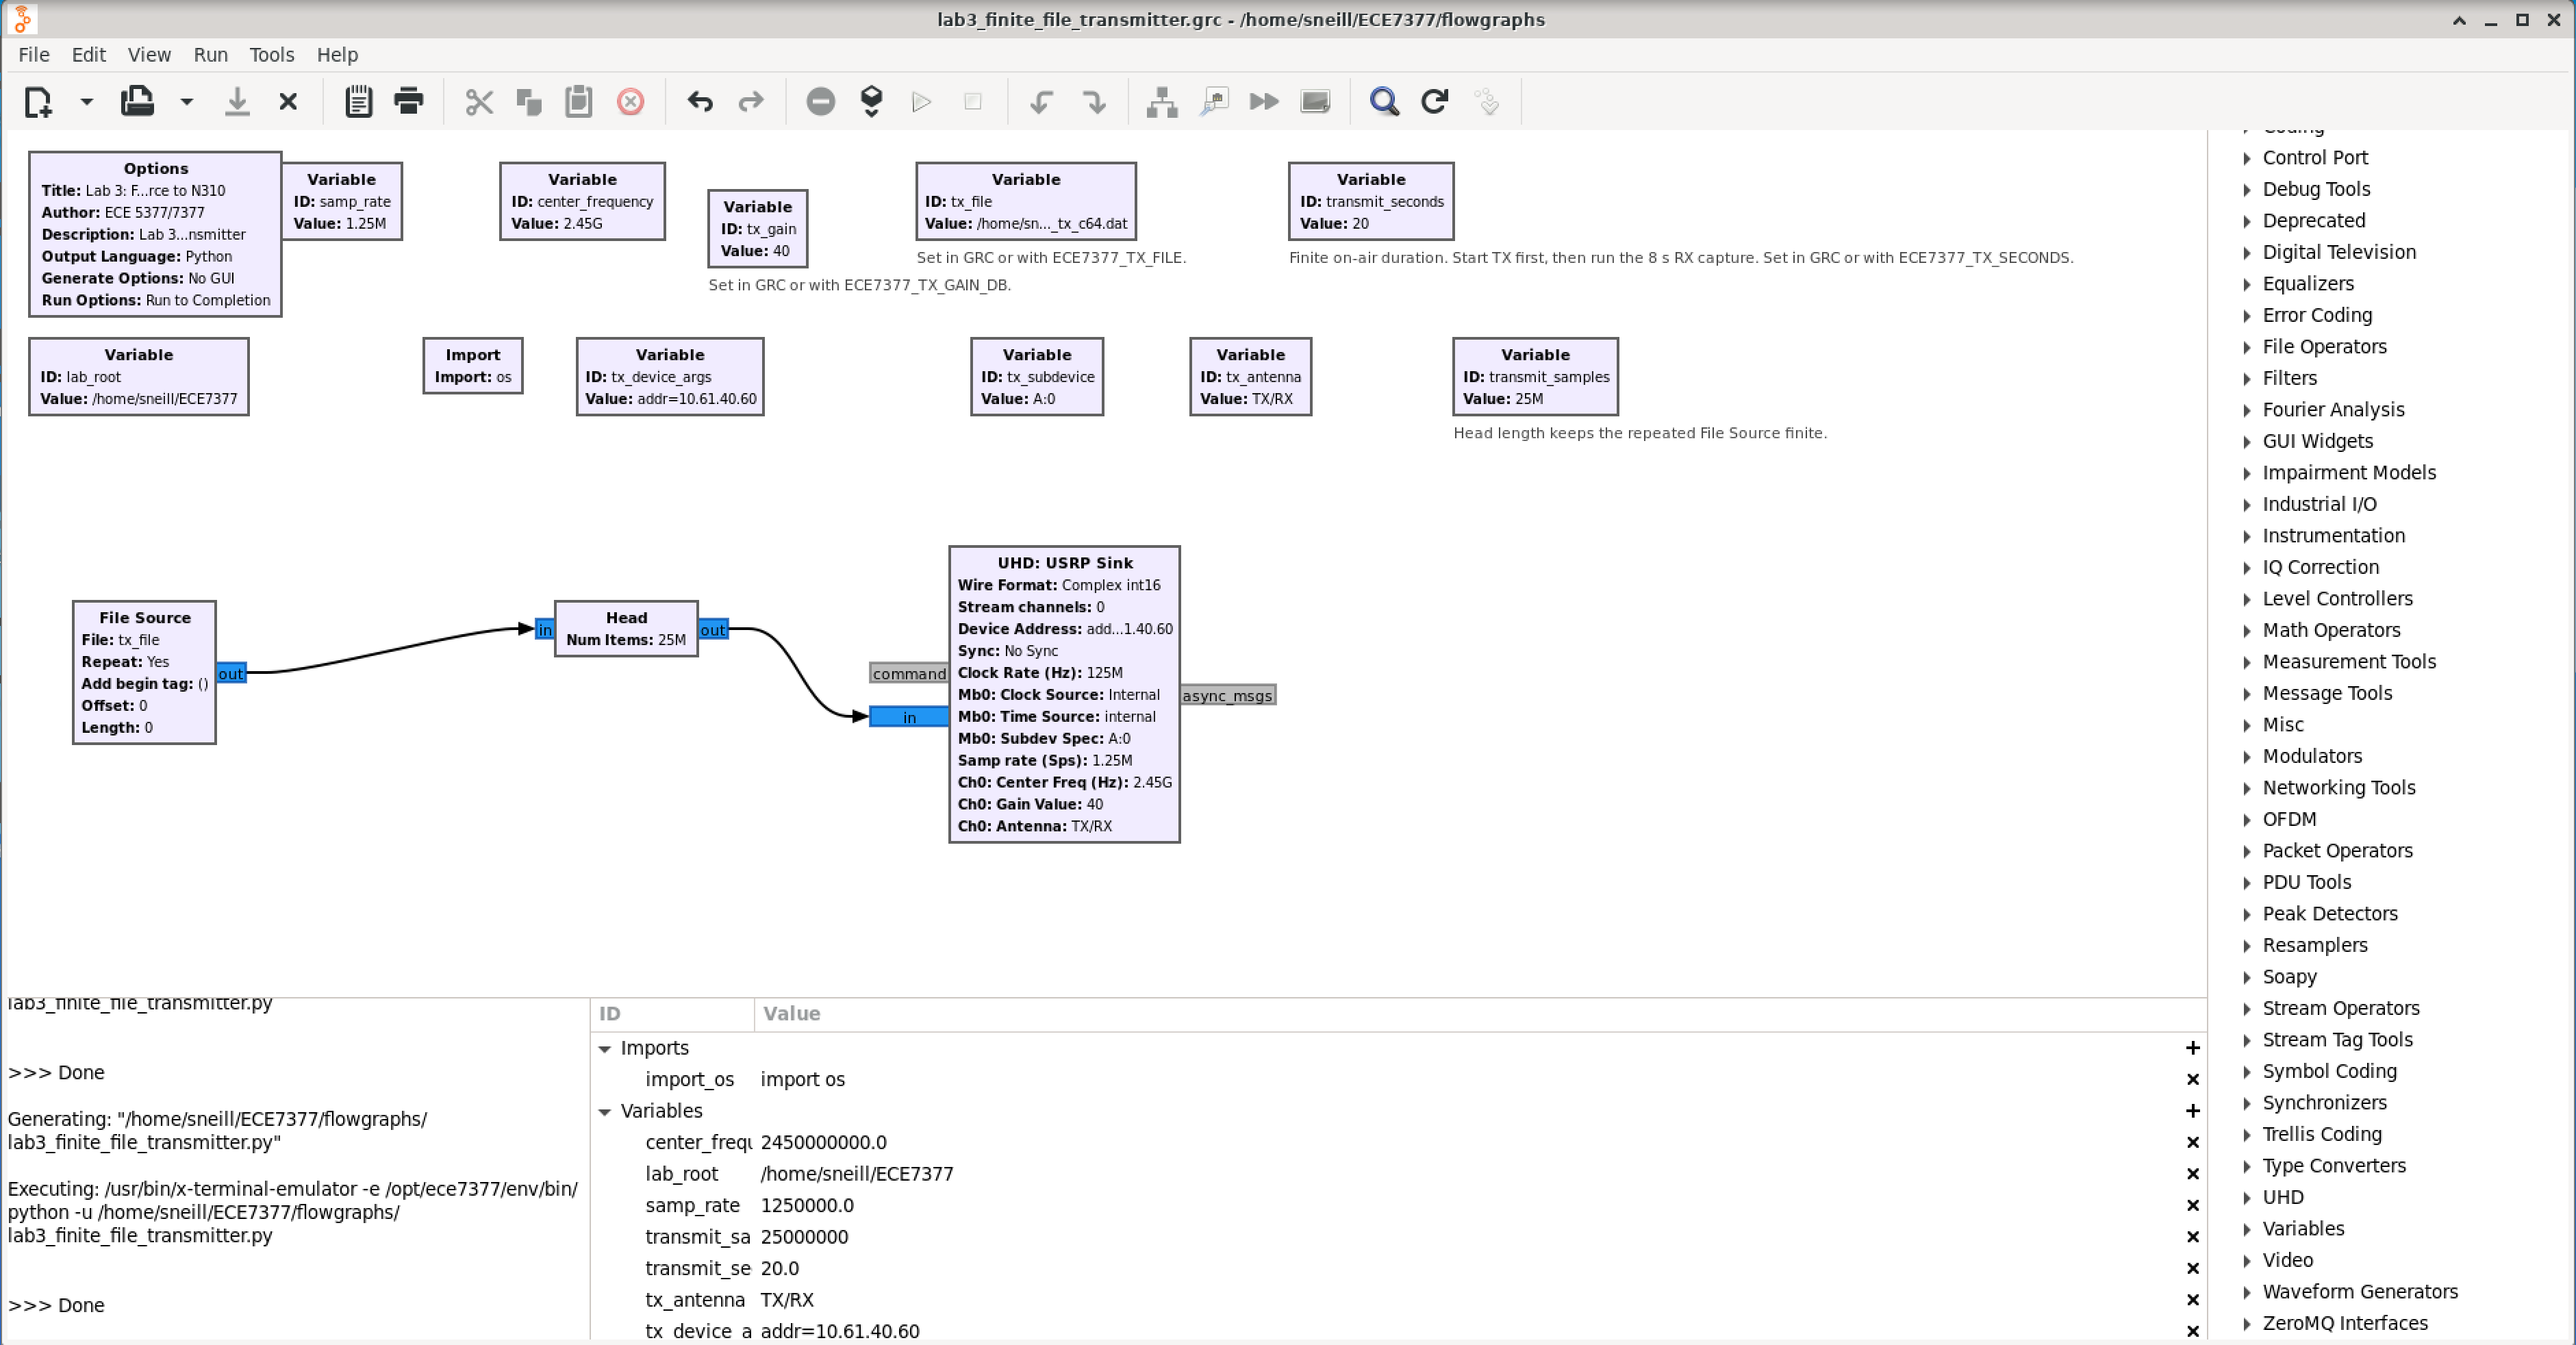

The receiver flowgraph consists of a UHD USRP Source that acquires samples from the assigned radio, a Head block (capture_samples) that sets the capture length, and a File Sink (output_file) that saves the complex64 samples. The server-supplied radio assignment is stored in the variables rx_device_args, rx_subdevice, and rx_antenna. The Head block limits the recording to either 1.0 s for noise captures or 8.0 s for signal captures, creating a finite output file. Note that the following screenshot uses a Task 4 output, which was originally set to Task 3 for this task.

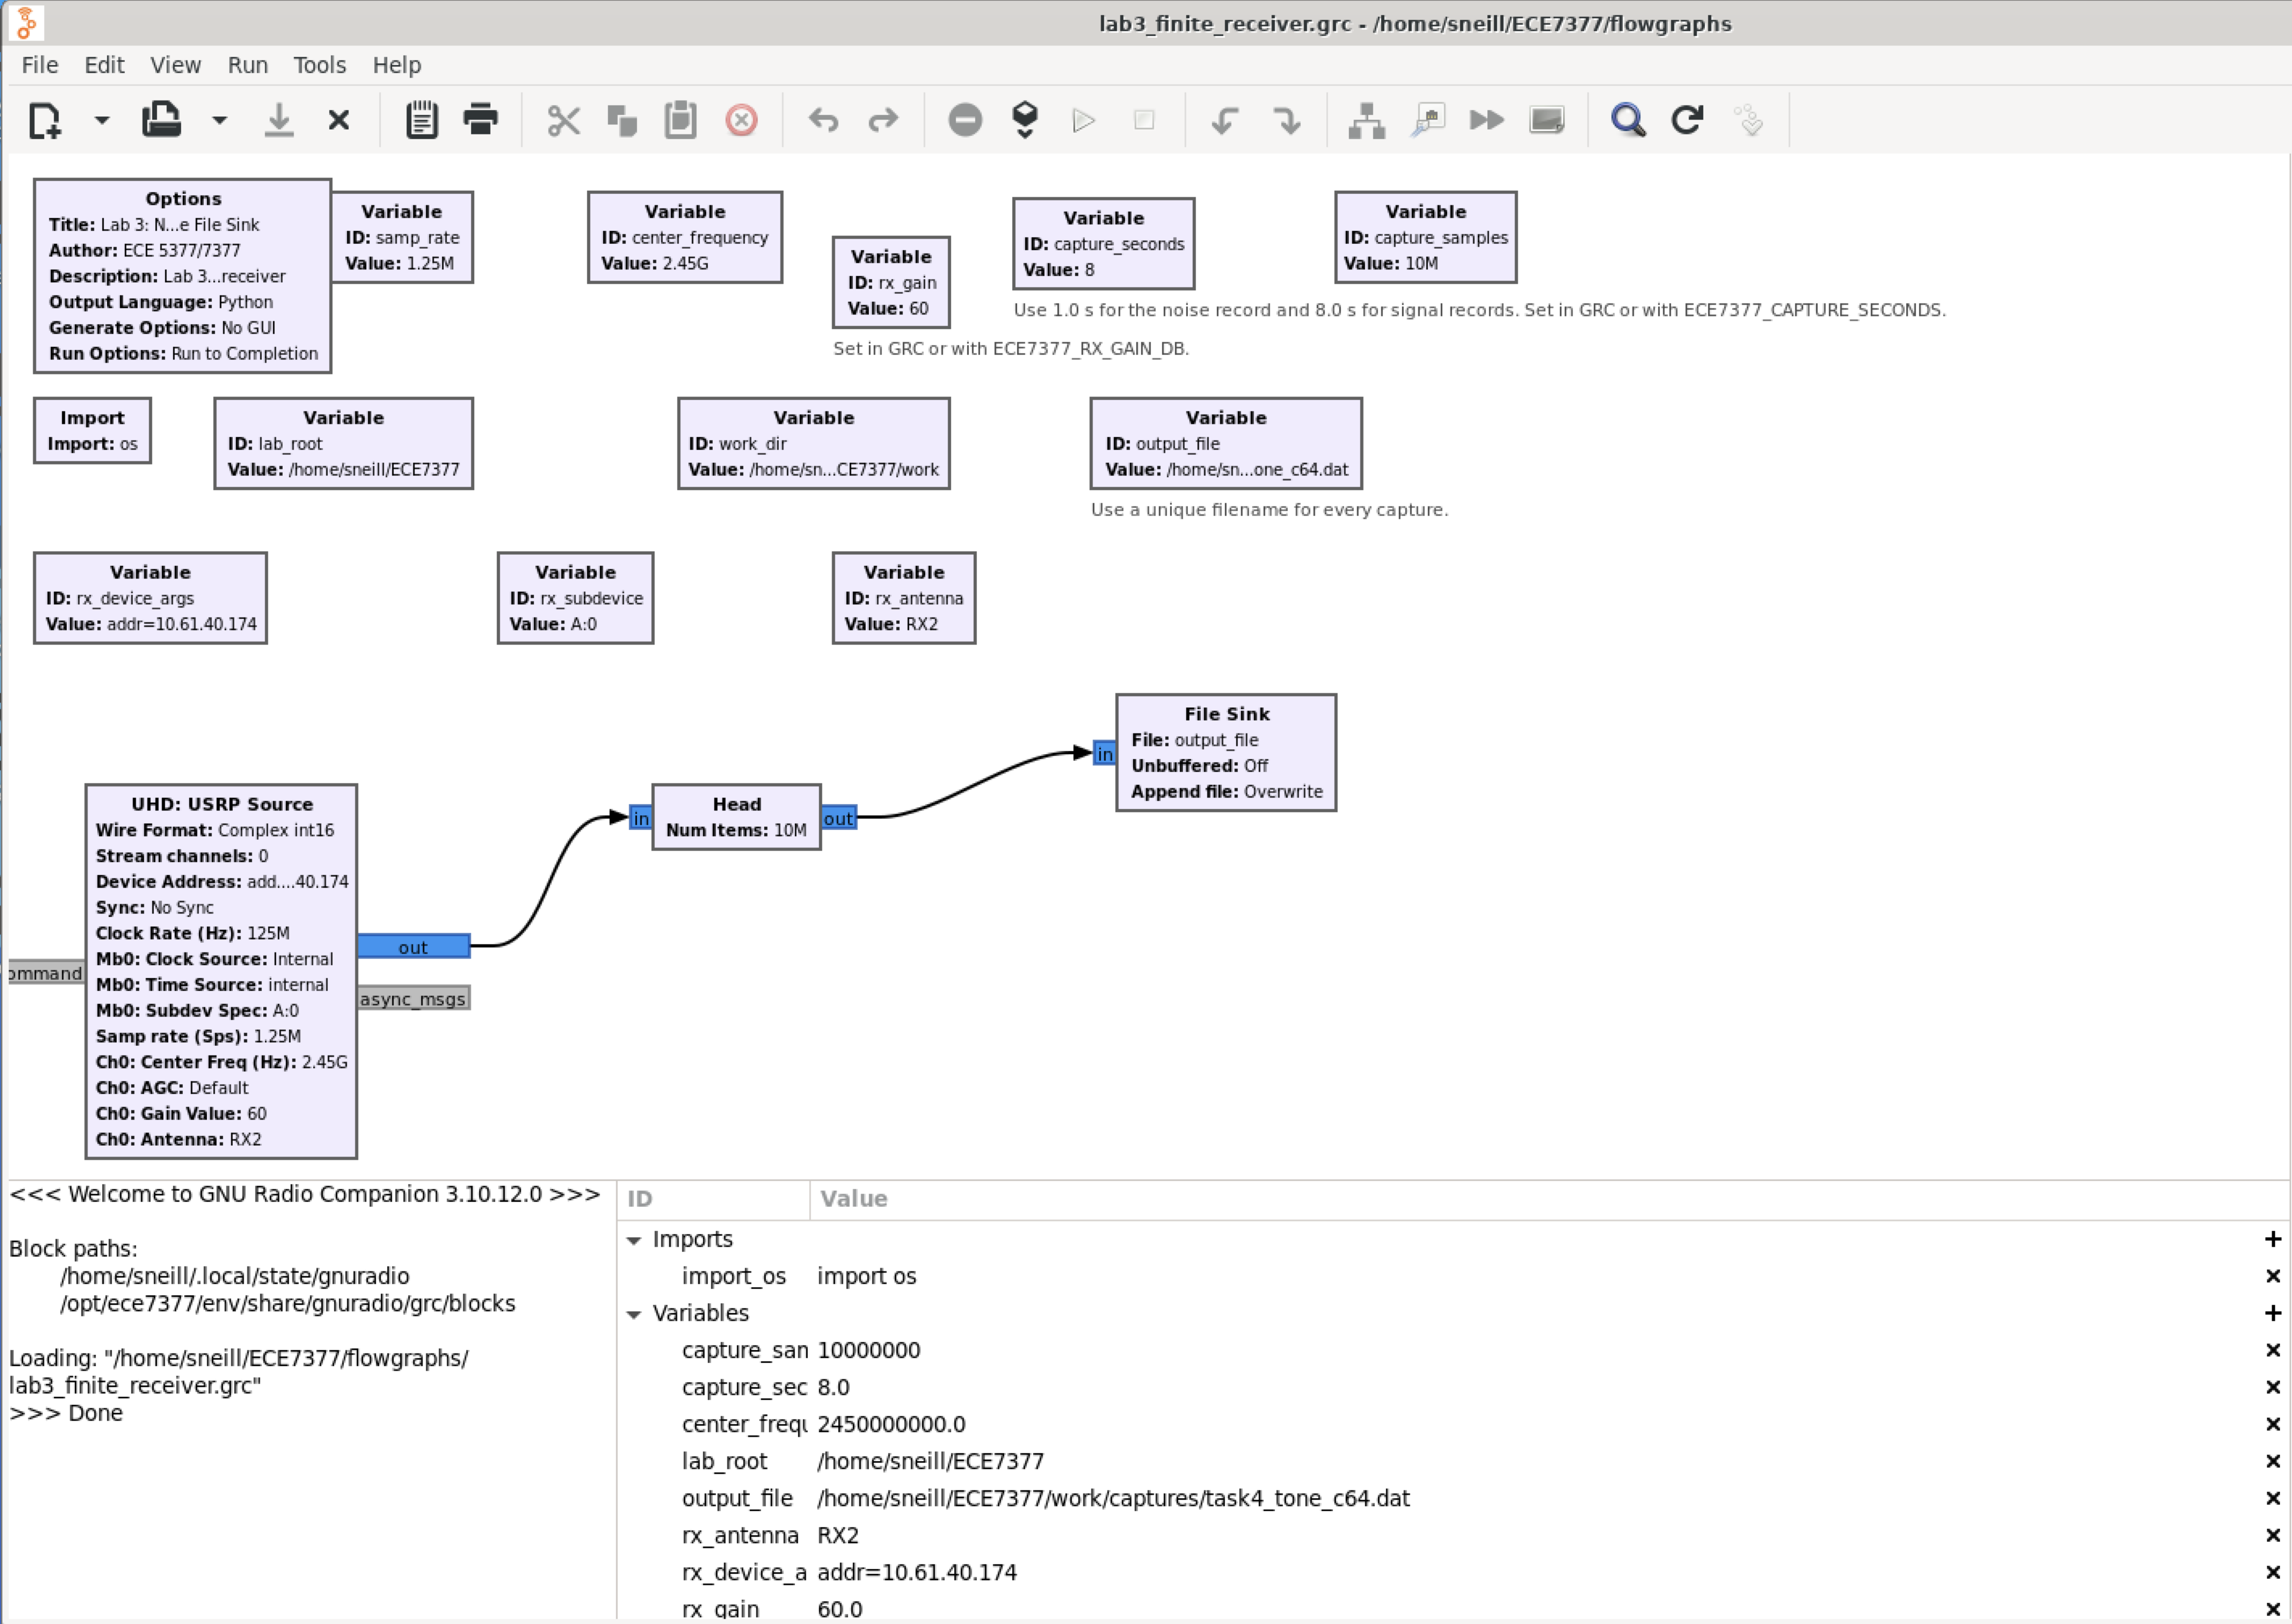

A Throttle block is not used because the USRP hardware already controls the sample rate at 1.25 MS/s. In a hardware streaming path, the UHD source or sink provides the timing reference and naturally regulates data flow. Adding a Throttle block could interfere with the hardware timing and is therefore unnecessary.

## Analyze the real captures

The expected filenames are `task3_m4_gain10_c64.dat`, `task3_m4_gain25_c64.dat`, `task3_m4_gain40_c64.dat`, and the corresponding `m8` files.

<span style="color:#165696"><b>Answer in the report.</b> Report gain, SNR, EVM, SER, BER, CFO, maximum magnitude, and exact
sample count.</span>

In [38]:
noise_path = CAPTURE_DIR / "task3_noise_c64.dat"
capture_names = [
    f"m{order}_gain{gain}"
    for order in (4, 8)
    for gain in (10, 25, 40)
]
required = [noise_path] + [CAPTURE_DIR / f"task3_{name}_c64.dat" for name in capture_names]
missing = [path for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError("Capture these files before analysis: " + ", ".join(path.name for path in missing))

records = {}
for name in capture_names:
    order = 4 if name.startswith("m4") else 8
    records[name] = analyze_psk_capture(
        CAPTURE_DIR / f"task3_{name}_c64.dat", noise_path, references[order]
    )
    record = records[name]
    samples = np.fromfile(capture_path, dtype=np.complex64)
    print(
        f"{name:11s} SNR={record['snr_db']:6.2f} dB  "
        f"EVM={record['evm_percent']:6.2f}%  SER={record['ser']:.6f}  "
        f"BER={record['ber']:.6f}  CFO={record['cfo_hz']:7.2f} Hz  "
        f"Sample Count={len(samples)}  Max Magnitude={np.max(np.abs(samples)):.4f}"
    )

m4_gain10   SNR= 23.41 dB  EVM=  2.47%  SER=0.000000  BER=0.000000  CFO= 100.90 Hz  Sample Count=10000000  Max Magnitude=0.0145
m4_gain25   SNR= 38.29 dB  EVM=  2.91%  SER=0.000000  BER=0.000000  CFO= 101.23 Hz  Sample Count=10000000  Max Magnitude=0.0145
m4_gain40   SNR= 55.57 dB  EVM=  1.58%  SER=0.000000  BER=0.000000  CFO=  98.89 Hz  Sample Count=10000000  Max Magnitude=0.0145
m8_gain10   SNR= 23.42 dB  EVM=  2.79%  SER=0.000000  BER=0.000000  CFO= 100.66 Hz  Sample Count=10000000  Max Magnitude=0.0145
m8_gain25   SNR= 38.30 dB  EVM=  1.71%  SER=0.000000  BER=0.000000  CFO= 100.26 Hz  Sample Count=10000000  Max Magnitude=0.0145
m8_gain40   SNR= 55.55 dB  EVM=  3.32%  SER=0.000000  BER=0.000000  CFO=  99.10 Hz  Sample Count=10000000  Max Magnitude=0.0145


<span style="color:#165696"><b>Answer in the report.</b> For QPSK and 8-PSK, compare low-, medium-, and high-SNR constellations
and decoded messages. Explain why 8-PSK is more sensitive to a similar angular error. Explain any result
that is not monotonic with TX gain.</span>

For both QPSK and 8-PSK, the constellation clusters became tighter and more distinct as TX gain increased, corresponding to the higher measured SNR. All six captures decoded the message "ECE7377 LAB3 PYTHON RADIO |" correctly with zero BER and SER. 8-PSK is more sensitive to angular error because its constellation points are separated by only 45 degrees, compared to 90 degrees for QPSK, leaving less angular margin before a symbol crosses a decision boundary.

Although SNR increased monotonically with TX gain, EVM did not. This is expected because EVM is affected not only by noise power but also by residual synchronization errors, phase noise, frequency-offset estimation, and other hardware impairments; additionally, Will's updated and more robust Python support file improved receiver synchronization and detection performance, reducing sensitivity to noise. As a result, the small EVM variations did not significantly impact performance, and all captures achieved zero BER and SER.

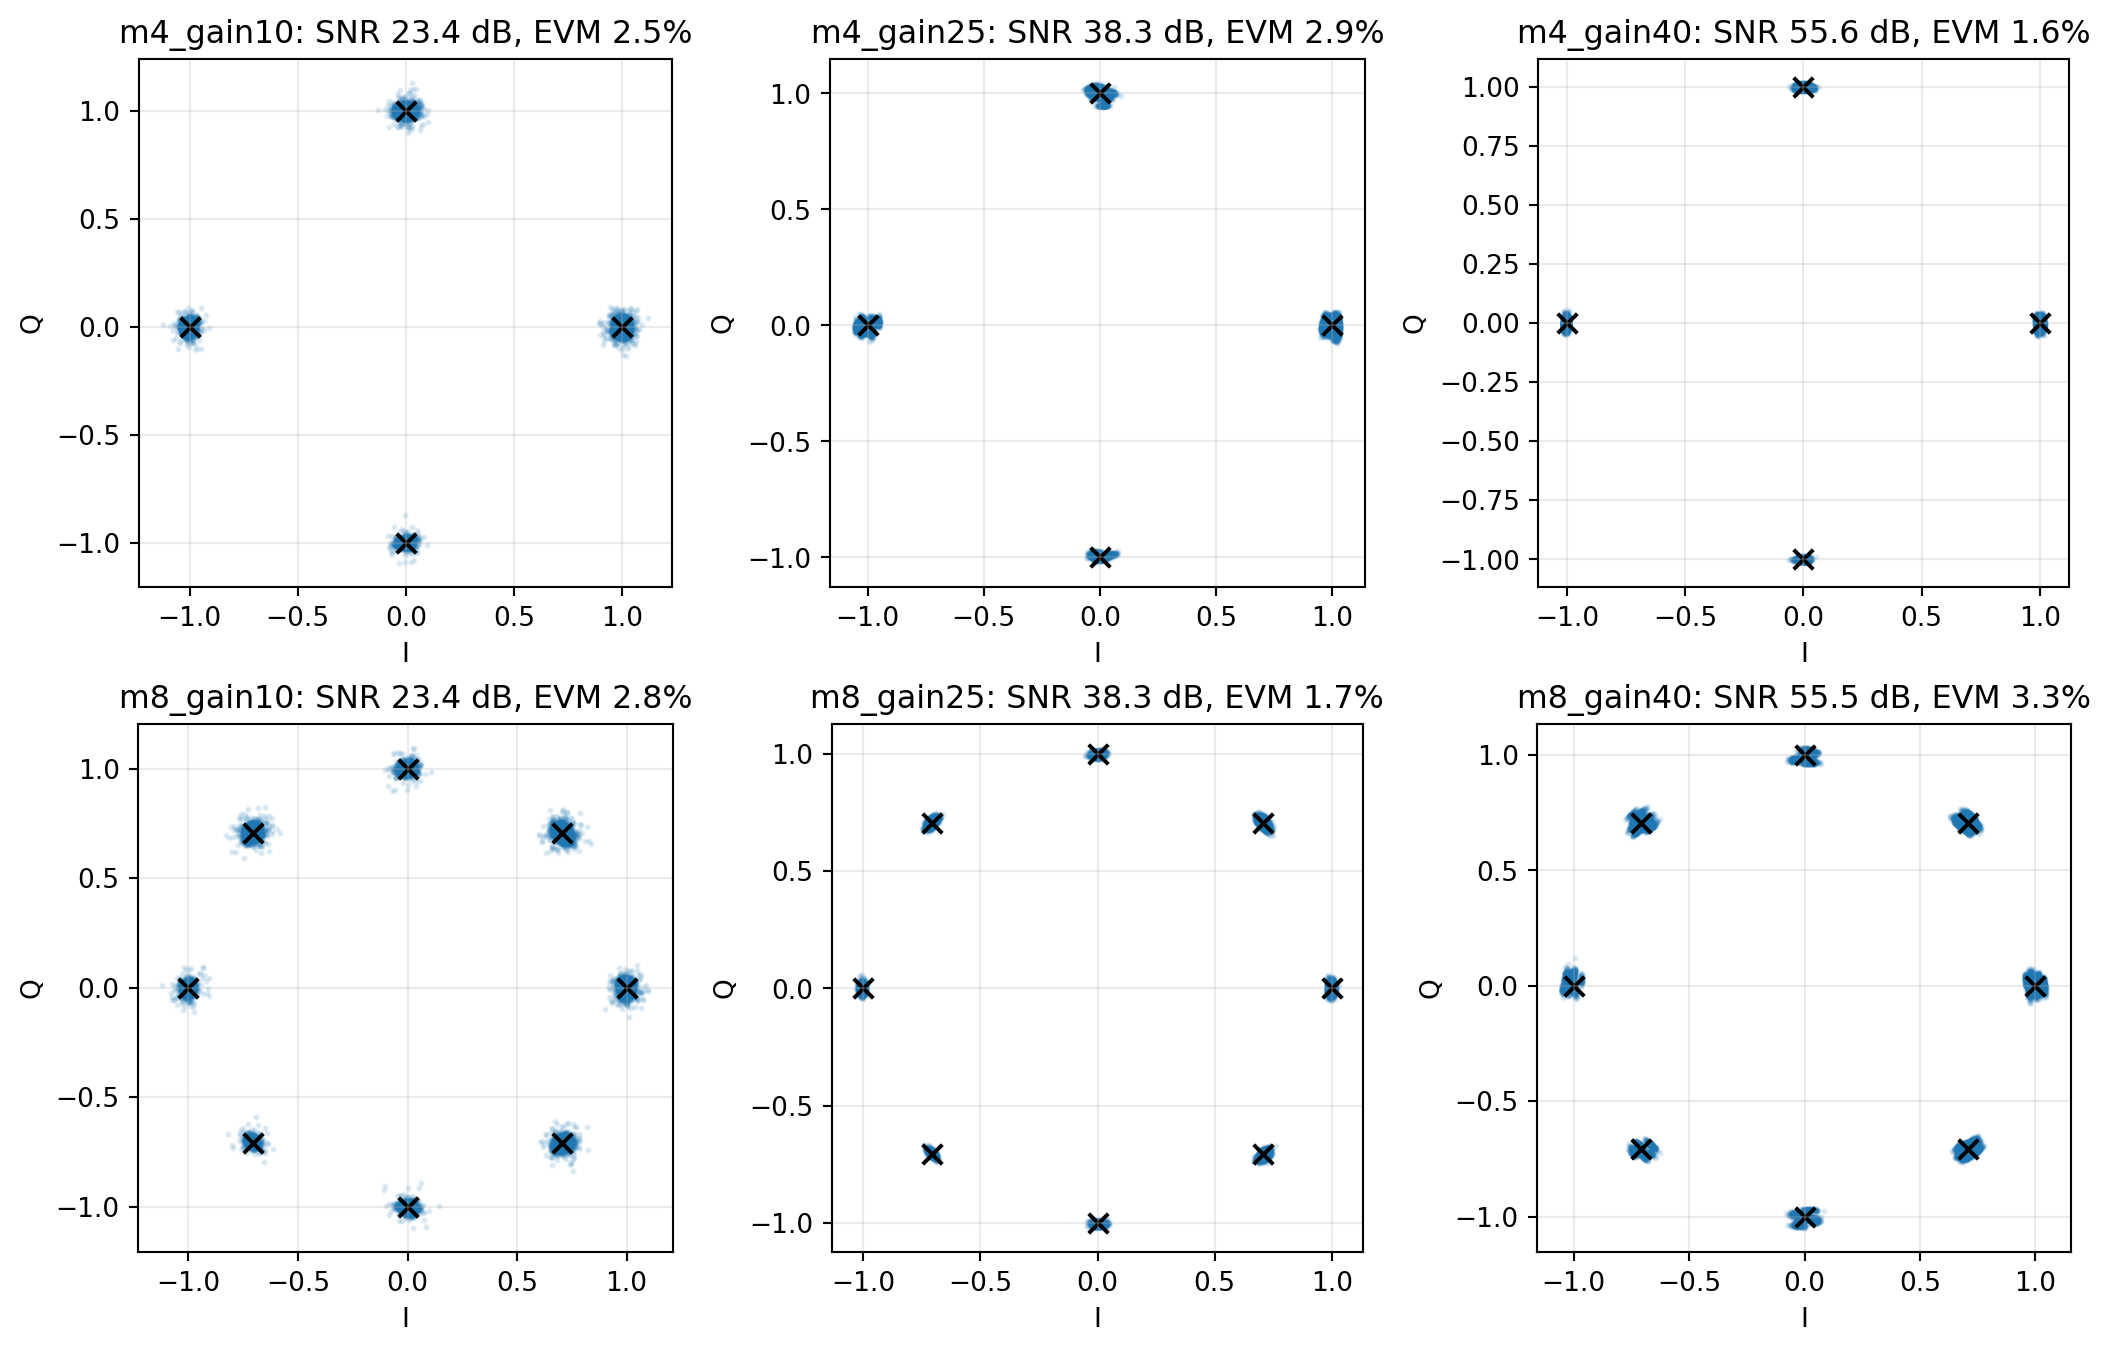

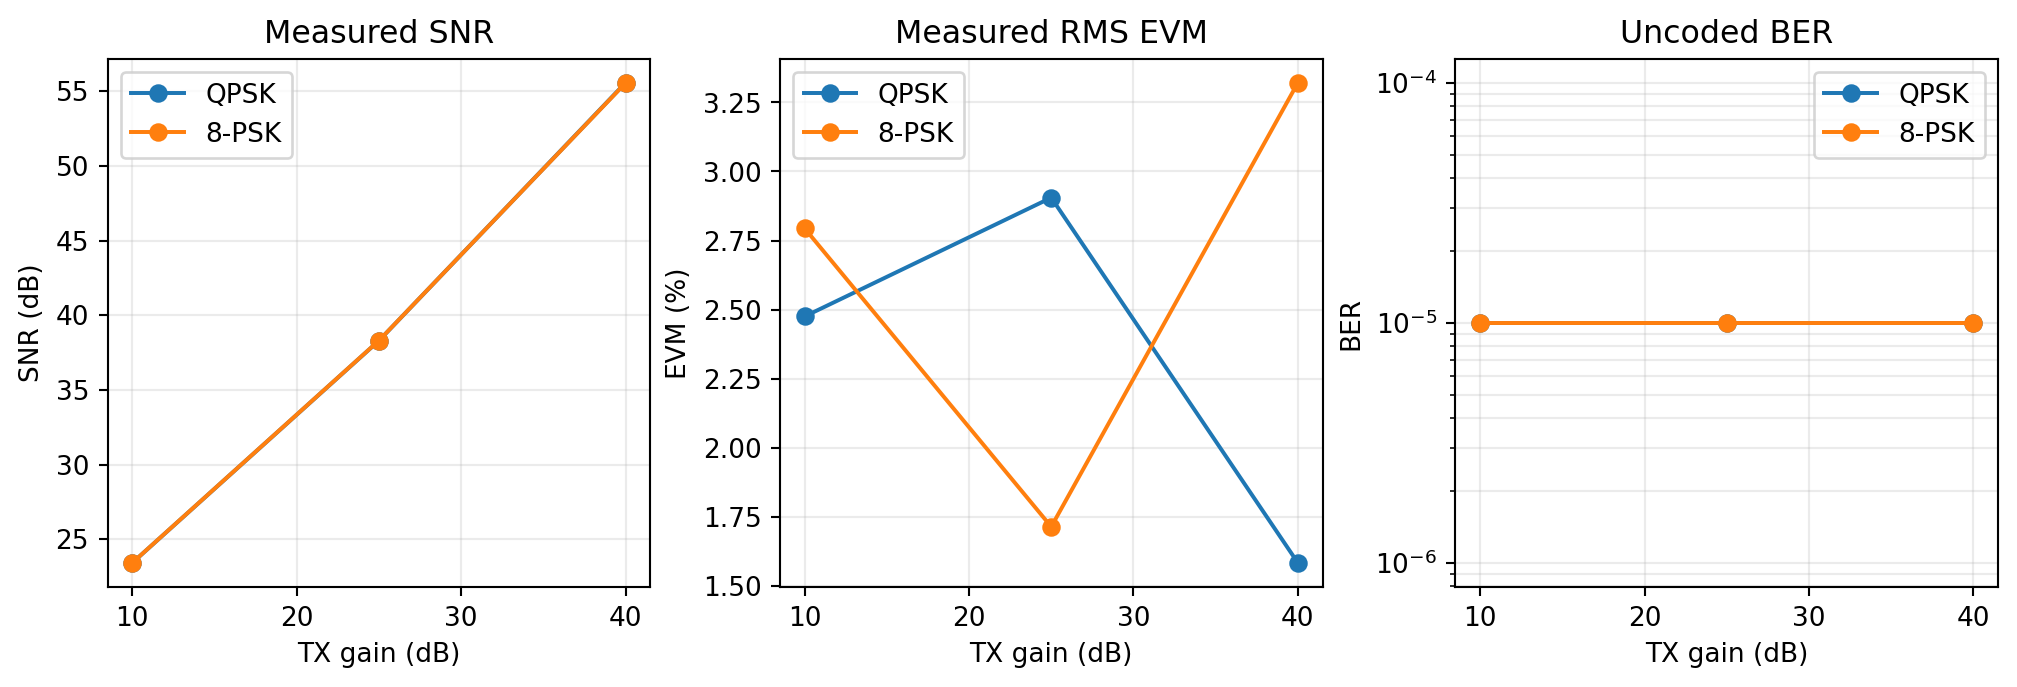

m4_gain10 decoded: ECE7377 LAB3 PYTHON RADIO | 
m4_gain25 decoded: ECE7377 LAB3 PYTHON RADIO | 
m4_gain40 decoded: ECE7377 LAB3 PYTHON RADIO | 
m8_gain10 decoded: ECE7377 LAB3 PYTHON RADIO | 
m8_gain25 decoded: ECE7377 LAB3 PYTHON RADIO | 
m8_gain40 decoded: ECE7377 LAB3 PYTHON RADIO | 


In [7]:
constellation_figure, metrics_figure = plot_task3_measurements(records, FIGURE_DIR)
display(Image(filename=str(constellation_figure)))
display(Image(filename=str(metrics_figure)))
for name, record in records.items():
    print(name, "decoded:", record["decoded_prefixes"][0])